# concrete_high パターン FFT解析
コンクリート壁 + 強換気(0.5 m³/s) の熱環境特性分析

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.fft import rfft, rfftfreq, irfft
from pathlib import Path
import os

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

# 出力ディレクトリ作成
os.makedirs("output_data", exist_ok=True)

## 1. データの読み込みと前処理

In [2]:
# ファイル設定
file_name_input = 'input_data/result_case0.2_all_rooms_high.csv'
file_name_output = "output_data/harmonic_analysis_results_concrete_high.xlsx"
file_name_output_fft = "output_data/harmonic_analysis_results_fft_concrete_high.xlsx"

print("=== concrete_high パターン FFT解析 ===")

=== concrete_high パターン FFT解析 ===


In [3]:
# データの読み込み
df = pd.read_csv(file_name_input, header=[0,1], index_col=0, parse_dates=True)

print(f"データ形状: {df.shape}")
print(f"列構造: {df.columns.tolist()}")
print(f"期間: {df.index[0]} ～ {df.index[-1]}")

# データ構造の確認
df.head()

データ形状: (18729, 6)
列構造: [('room1', 'temp'), ('room1', 'rh'), ('room1', 'ah'), ('room2', 'temp'), ('room2', 'rh'), ('room2', 'ah')]
期間: 2022-04-01 00:00:00 ～ NaT


room1                   room2                
                     temp     rh       ah    temp     rh       ah
2022-04-01 00:00:00   9.4  0.890  0.00651  24.539  0.495  0.00952
2022-04-01 00:10:00   9.4  0.886  0.00648  11.284  0.796  0.00660
2022-04-01 00:20:00   9.4  0.881  0.00644  11.133  0.795  0.00653
2022-04-01 00:30:00   9.4  0.876  0.00640  11.037  0.793  0.00647
2022-04-01 00:40:00   9.4  0.870  0.00637  10.968  0.791  0.00642

In [4]:
# room2の温度データを選択（NaNを除去）
temp_series = df[('room2', 'temp')].dropna()
target_data = temp_series.values
valid_index = temp_series.index

td = pd.Timedelta(valid_index[1] - valid_index[0])
sampling_rate = td.total_seconds()

print(f"サンプリング間隔: {sampling_rate}秒 ({sampling_rate/60:.1f}分)")
print(f"解析対象: room2室内温度 ({len(target_data)}点)")
print(f"温度範囲: {target_data.min():.2f}°C ～ {target_data.max():.2f}°C")
print(f"有効期間: {valid_index[0]} ～ {valid_index[-1]}")
print(f"NaN除去: {df.shape[0] - len(target_data)}点")

サンプリング間隔: 600.0秒 (10.0分)
解析対象: room2室内温度 (17568点)
温度範囲: 5.38°C ～ 36.97°C
有効期間: 2022-04-01 00:00:00 ～ 2022-07-31 23:50:00
NaN除去: 1161点


## 2. 元データの可視化

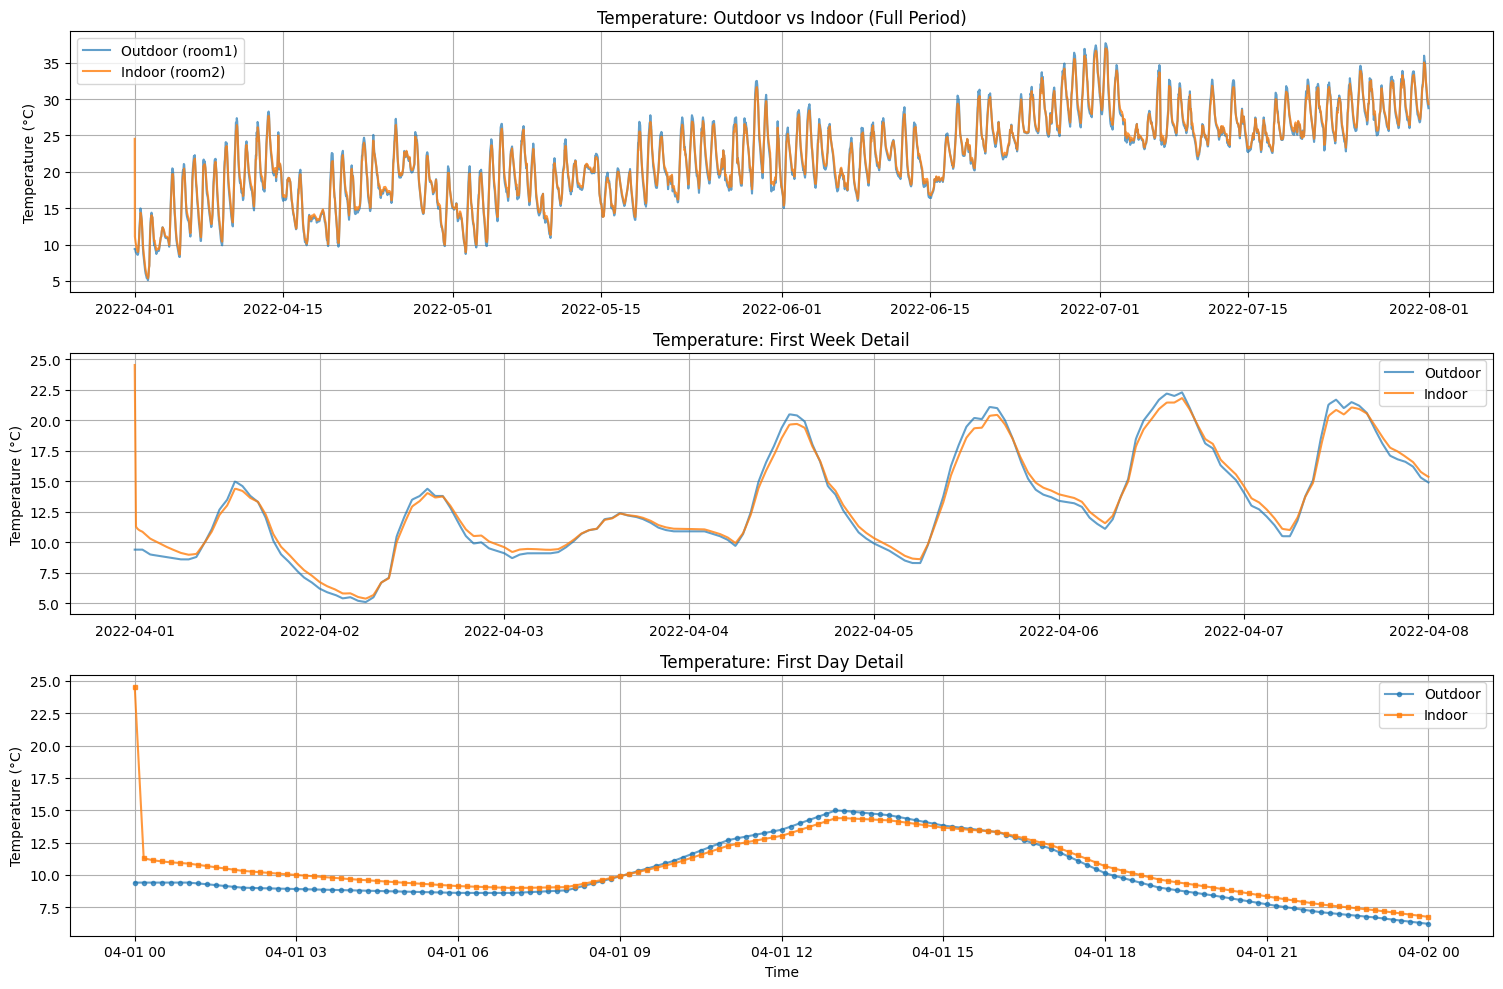

In [5]:
# 元データのプロット
plt.figure(figsize=(15, 10))

# 全期間のデータ
plt.subplot(3, 1, 1)
outdoor_temp = df[('room1', 'temp')].dropna()
plt.plot(outdoor_temp.index, outdoor_temp.values, label='Outdoor (room1)', alpha=0.7)
plt.plot(valid_index, target_data, label='Indoor (room2)', alpha=0.8)
plt.title('Temperature: Outdoor vs Indoor (Full Period)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# 最初の1週間
plt.subplot(3, 1, 2)
week_mask = valid_index <= valid_index[0] + pd.Timedelta(days=7)
week_index = valid_index[week_mask]
week_data = target_data[week_mask]
outdoor_week = outdoor_temp[outdoor_temp.index <= outdoor_temp.index[0] + pd.Timedelta(days=7)]

plt.plot(outdoor_week.index, outdoor_week.values, label='Outdoor', alpha=0.7)
plt.plot(week_index, week_data, label='Indoor', alpha=0.8)
plt.title('Temperature: First Week Detail')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# 1日の詳細
plt.subplot(3, 1, 3)
day_mask = valid_index <= valid_index[0] + pd.Timedelta(days=1)
day_index = valid_index[day_mask]
day_data = target_data[day_mask]
outdoor_day = outdoor_temp[outdoor_temp.index <= outdoor_temp.index[0] + pd.Timedelta(days=1)]

plt.plot(outdoor_day.index, outdoor_day.values, label='Outdoor', alpha=0.7, marker='o', markersize=3)
plt.plot(day_index, day_data, label='Indoor', alpha=0.8, marker='s', markersize=3)
plt.title('Temperature: First Day Detail')
plt.ylabel('Temperature (°C)')
plt.xlabel('Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. フーリエ変換の実行

In [6]:
# フーリエ変換の実行
target_array = target_data.flatten()
fft_result = rfft(target_array)
freqs = rfftfreq(len(target_data), d=sampling_rate)

# 振幅と位相を計算
amplitudes = np.abs(fft_result) / len(target_data)
phases = np.angle(fft_result)

# 逆フーリエ変換
reconstructed = irfft(fft_result)

print(f"フーリエ変換完了: {len(freqs)}周波数成分")

フーリエ変換完了: 8785周波数成分


## 4. 周波数スペクトルの可視化

/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3445524371.py:2: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs != 0, 1 / freqs / 86400, np.nan)


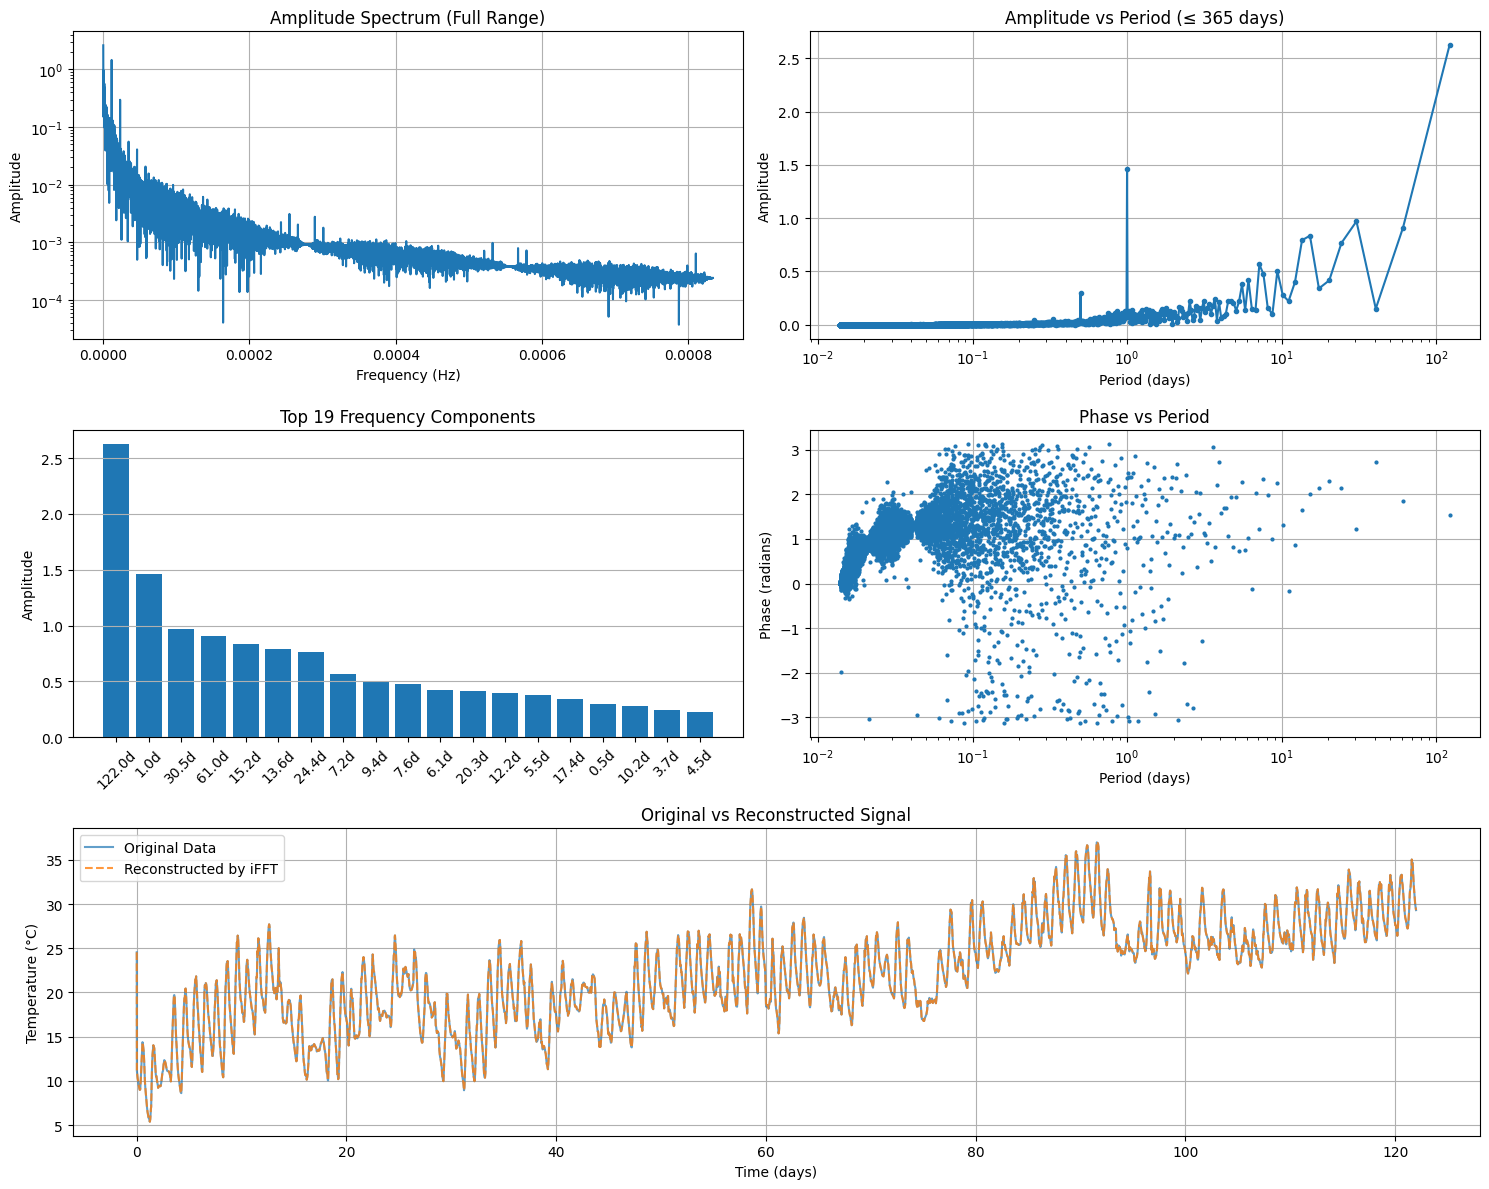

In [7]:
# 周期に変換（日単位）
periods = np.where(freqs != 0, 1 / freqs / 86400, np.nan)

# スペクトルのプロット
plt.figure(figsize=(15, 12))

# 振幅スペクトル（全範囲）
plt.subplot(3, 2, 1)
plt.plot(freqs[1:], amplitudes[1:])  # DC成分を除く
plt.title('Amplitude Spectrum (Full Range)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.yscale('log')

# 振幅スペクトル（周期表示、主要成分）
plt.subplot(3, 2, 2)
valid_periods = periods[~np.isnan(periods) & (periods <= 365)]  # 1年以下
valid_amplitudes = amplitudes[~np.isnan(periods) & (periods <= 365)]
plt.plot(valid_periods, valid_amplitudes, 'o-', markersize=3)
plt.title('Amplitude vs Period (≤ 365 days)')
plt.xlabel('Period (days)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xscale('log')

# 主要な周期成分（棒グラフ）
plt.subplot(3, 2, 3)
top_n = 20
indices = np.argsort(amplitudes)[-top_n:][::-1]
top_amplitudes = amplitudes[indices]
top_periods = periods[indices]

# DC成分を除く
non_dc_mask = ~np.isnan(top_periods)
if non_dc_mask.sum() > 0:
    plt.bar(range(non_dc_mask.sum()), top_amplitudes[non_dc_mask])
    period_labels = [f'{p:.1f}d' if not np.isnan(p) else 'DC' for p in top_periods[non_dc_mask]]
    plt.xticks(range(len(period_labels)), period_labels, rotation=45)
plt.title(f'Top {non_dc_mask.sum()} Frequency Components')
plt.ylabel('Amplitude')
plt.grid(True, axis='y')

# 位相スペクトル
plt.subplot(3, 2, 4)
plt.plot(valid_periods, phases[~np.isnan(periods) & (periods <= 365)], 'o', markersize=2)
plt.title('Phase vs Period')
plt.xlabel('Period (days)')
plt.ylabel('Phase (radians)')
plt.grid(True)
plt.xscale('log')

# 元データと再構成データの比較
plt.subplot(3, 1, 3)
time_days = np.arange(len(target_array)) * sampling_rate / 86400
plt.plot(time_days, target_array, label='Original Data', alpha=0.7)
plt.plot(time_days, reconstructed, label='Reconstructed by iFFT', linestyle='--', alpha=0.8)
plt.title('Original vs Reconstructed Signal')
plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. 主要周波数成分の分析

In [8]:
# 主要周波数成分の抽出と表示
top_n = 20
indices = np.argsort(amplitudes)[-top_n:][::-1]
top_amplitudes = amplitudes[indices]
top_frequencies = freqs[indices]
top_periods = periods[indices]

print("=== 主要周波数成分分析 ===")
print(f"DC成分（平均値）: {amplitudes[0]:.2f}°C")
print("\n上位周波数成分:")

results_table = []
for i, (freq, amp, period) in enumerate(zip(top_frequencies, top_amplitudes, top_periods), 1):
    if freq == 0:
        period_str = "DC成分"
        freq_str = "0 Hz"
    else:
        period_str = f"{period:.1f}日"
        freq_str = f"{freq:.2e} Hz"
    
    results_table.append({
        'Rank': i,
        'Period': period_str,
        'Frequency': freq_str,
        'Amplitude': f"{amp:.6f}°C"
    })
    
    print(f"  {i:2d}. 周期: {period_str:>10s}, 振幅: {amp:.6f}°C")

# DataFrame化
results_df = pd.DataFrame(results_table)
print(f"\n解析対象期間: {time_days[-1]:.1f}日")
print(f"温度変動範囲: {target_array.min():.2f}°C ～ {target_array.max():.2f}°C")

=== 主要周波数成分分析 ===
DC成分（平均値）: 22.08°C

上位周波数成分:
   1. 周期:       DC成分, 振幅: 22.083338°C
   2. 周期:     122.0日, 振幅: 2.622549°C
   3. 周期:       1.0日, 振幅: 1.460377°C
   4. 周期:      30.5日, 振幅: 0.970388°C
   5. 周期:      61.0日, 振幅: 0.910456°C
   6. 周期:      15.2日, 振幅: 0.835446°C
   7. 周期:      13.6日, 振幅: 0.793260°C
   8. 周期:      24.4日, 振幅: 0.767708°C
   9. 周期:       7.2日, 振幅: 0.565814°C
  10. 周期:       9.4日, 振幅: 0.503331°C
  11. 周期:       7.6日, 振幅: 0.475205°C
  12. 周期:       6.1日, 振幅: 0.420282°C
  13. 周期:      20.3日, 振幅: 0.416289°C
  14. 周期:      12.2日, 振幅: 0.399783°C
  15. 周期:       5.5日, 振幅: 0.379057°C
  16. 周期:      17.4日, 振幅: 0.340108°C
  17. 周期:       0.5日, 振幅: 0.297720°C
  18. 周期:      10.2日, 振幅: 0.278620°C
  19. 周期:       3.7日, 振幅: 0.244502°C
  20. 周期:       4.5日, 振幅: 0.226779°C

解析対象期間: 122.0日
温度変動範囲: 5.38°C ～ 36.97°C


## 6. 周期範囲別の分析

=== 周期範囲別分析 ===
日内変動 (< 1日): 8663成分, 最大振幅: 1.4604°C (周期: 1.0日), パワー: 2.6309
週内変動 (1-7日): 105成分, 最大振幅: 1.4604°C (周期: 1.0日), パワー: 3.8018
月内変動 (7-30日): 13成分, 最大振幅: 0.8354°C (周期: 15.2日), パワー: 3.3261
季節変動 (30-365日): 4成分, 最大振幅: 2.6225°C (周期: 122.0日), パワー: 8.6711
年間変動 (> 365日): 0成分, 最大振幅: 0.0000°C (周期: 0.0日), パワー: 0.0000


/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3844529540.py:3: RuntimeWarning: divide by zero encountered in divide
  periods = 1 / freqs / 86400  # 日単位の周期
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3844529540.py:64: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3844529540.py:64: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3844529540.py:64: UserWarning: Glyph 22793 (\N{CJK UNIFIED IDEOGRAPH-5909}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/3844529540.py:64: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0

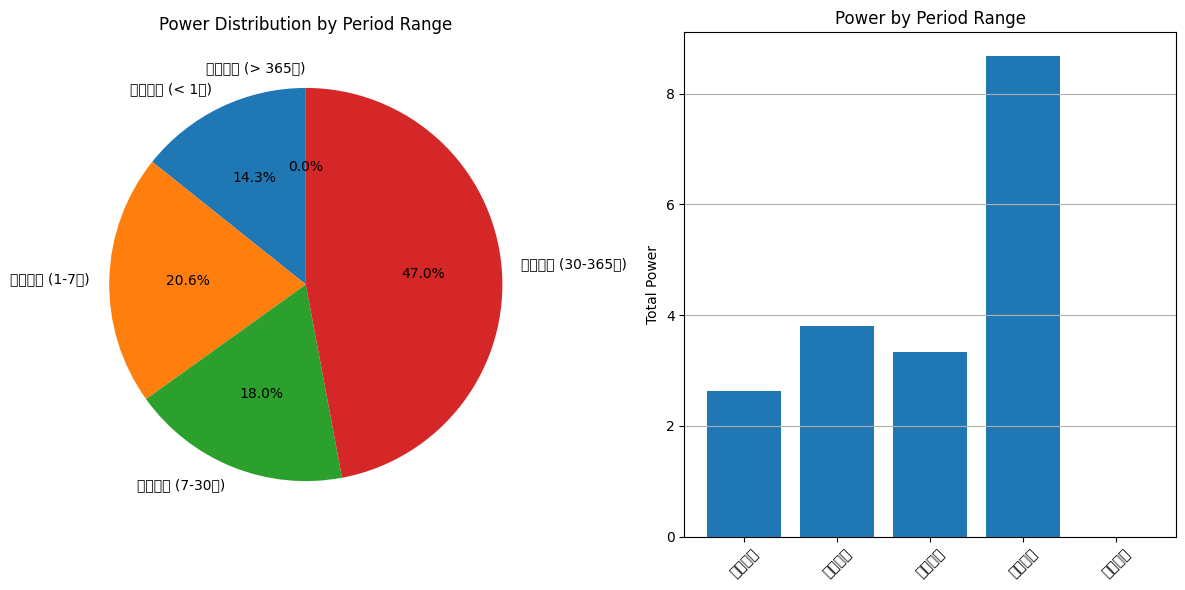

In [9]:
# 周期範囲別分析
def analyze_period_range(freqs, amplitudes, min_days, max_days, label):
    periods = 1 / freqs / 86400  # 日単位の周期
    mask = (periods >= min_days) & (periods <= max_days) & (freqs > 0)
    
    if mask.sum() > 0:
        range_amplitudes = amplitudes[mask]
        range_periods = periods[mask]
        max_idx = np.argmax(range_amplitudes)
        max_amp = range_amplitudes[max_idx]
        max_period = range_periods[max_idx]
        count = mask.sum()
        total_power = (range_amplitudes ** 2).sum()
        
        return {
            'range': label,
            'count': count,
            'max_amplitude': max_amp,
            'max_period': max_period,
            'total_power': total_power
        }
    else:
        return {
            'range': label,
            'count': 0,
            'max_amplitude': 0,
            'max_period': 0,
            'total_power': 0
        }

print("=== 周期範囲別分析 ===")
ranges = [
    (0, 1, "日内変動 (< 1日)"),
    (1, 7, "週内変動 (1-7日)"),
    (7, 30, "月内変動 (7-30日)"),
    (30, 365, "季節変動 (30-365日)"),
    (365, 1000, "年間変動 (> 365日)")
]

range_results = []
for min_days, max_days, label in ranges:
    result = analyze_period_range(freqs, amplitudes, min_days, max_days, label)
    range_results.append(result)
    print(f"{label}: {result['count']}成分, 最大振幅: {result['max_amplitude']:.4f}°C (周期: {result['max_period']:.1f}日), パワー: {result['total_power']:.4f}")

# パワー分布の可視化
plt.figure(figsize=(12, 6))

labels = [r['range'] for r in range_results]
powers = [r['total_power'] for r in range_results]
counts = [r['count'] for r in range_results]

plt.subplot(1, 2, 1)
plt.pie(powers, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Power Distribution by Period Range')

plt.subplot(1, 2, 2)
plt.bar(range(len(labels)), powers)
plt.xticks(range(len(labels)), [l.split(' ')[0] for l in labels], rotation=45)
plt.ylabel('Total Power')
plt.title('Power by Period Range')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

## 7. 再構成精度の評価

=== 再構成精度評価 ===
平均二乗誤差 (MSE): 0.000000
平均平方根誤差 (RMSE): 0.000000°C
平均絶対誤差 (MAE): 0.000000°C
決定係数 (R²): 1.000000


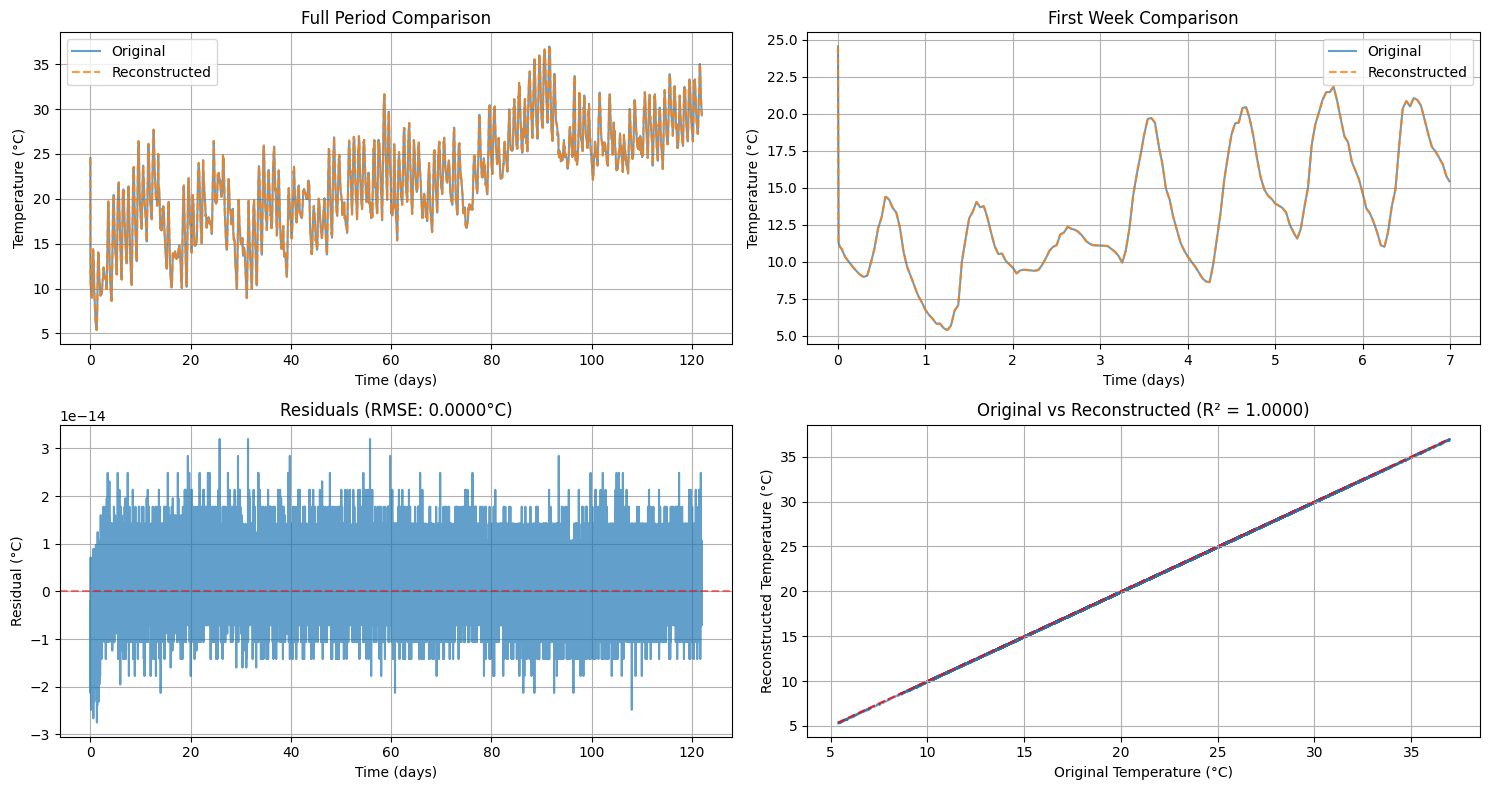

In [10]:
# 再構成精度の評価
original = target_array
reconstructed_fit = reconstructed[:len(original)]

mse = np.mean((original - reconstructed_fit) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(original - reconstructed_fit))
r2 = np.corrcoef(original, reconstructed_fit)[0, 1] ** 2

print("=== 再構成精度評価 ===")
print(f"平均二乗誤差 (MSE): {mse:.6f}")
print(f"平均平方根誤差 (RMSE): {rmse:.6f}°C")
print(f"平均絶対誤差 (MAE): {mae:.6f}°C")
print(f"決定係数 (R²): {r2:.6f}")

# 詳細比較プロット
plt.figure(figsize=(15, 8))

# 全期間の比較
plt.subplot(2, 2, 1)
plt.plot(time_days, original, label='Original', alpha=0.7)
plt.plot(time_days, reconstructed_fit, label='Reconstructed', linestyle='--', alpha=0.8)
plt.title('Full Period Comparison')
plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# 最初の1週間の比較
plt.subplot(2, 2, 2)
week_points = int(7 * 24 * 60 / (sampling_rate / 60))  # 1週間分のデータ点数
plt.plot(time_days[:week_points], original[:week_points], label='Original', alpha=0.7)
plt.plot(time_days[:week_points], reconstructed_fit[:week_points], label='Reconstructed', linestyle='--', alpha=0.8)
plt.title('First Week Comparison')
plt.xlabel('Time (days)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# 残差プロット
plt.subplot(2, 2, 3)
residuals = original - reconstructed_fit
plt.plot(time_days, residuals, alpha=0.7)
plt.title(f'Residuals (RMSE: {rmse:.4f}°C)')
plt.xlabel('Time (days)')
plt.ylabel('Residual (°C)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 散布図
plt.subplot(2, 2, 4)
plt.scatter(original, reconstructed_fit, alpha=0.5, s=1)
min_val = min(original.min(), reconstructed_fit.min())
max_val = max(original.max(), reconstructed_fit.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
plt.title(f'Original vs Reconstructed (R² = {r2:.4f})')
plt.xlabel('Original Temperature (°C)')
plt.ylabel('Reconstructed Temperature (°C)')
plt.grid(True)

plt.tight_layout()
plt.show()

## 8. 外気との比較分析

=== 外気との比較分析 ===
外気温度範囲: 5.10°C ～ 37.69°C
室内温度範囲: 5.38°C ～ 36.97°C
外気変動幅: 32.58°C
室内変動幅: 31.59°C
変動幅抑制率: 3.1%
外気-室内温度相関係数: 0.9975


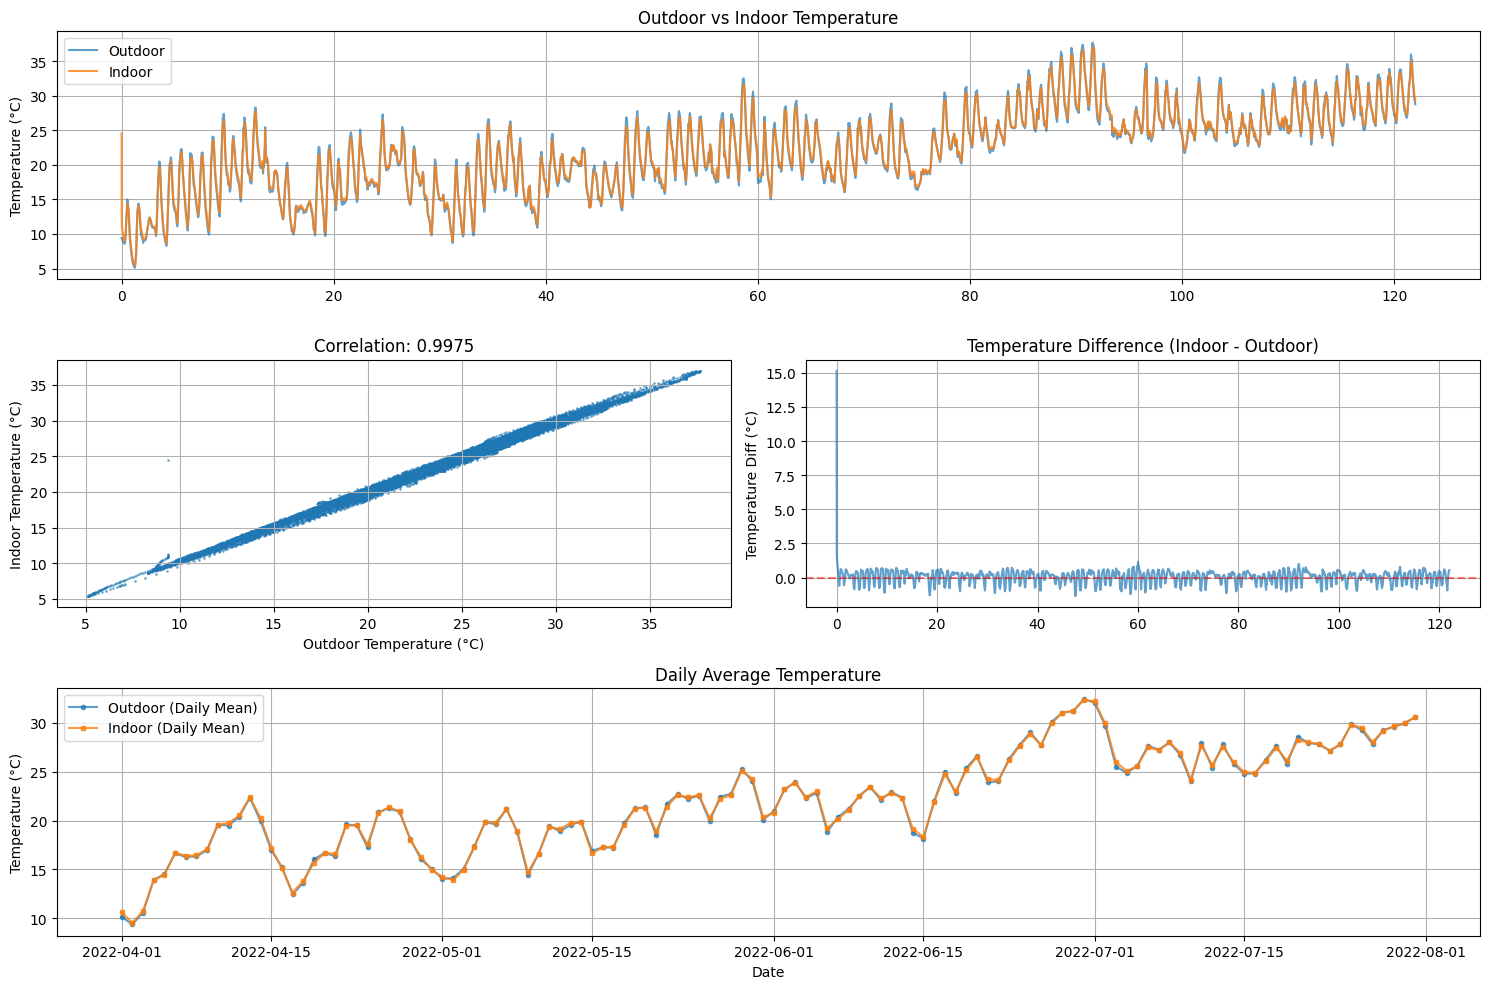

In [11]:
# 外気データとの比較
outdoor_series = df[('room1', 'temp')].dropna()
# 時間を合わせる
common_index = outdoor_series.index.intersection(valid_index)
outdoor_common = outdoor_series[common_index].values
indoor_common = temp_series[common_index].values

print("=== 外気との比較分析 ===")
print(f"外気温度範囲: {outdoor_common.min():.2f}°C ～ {outdoor_common.max():.2f}°C")
print(f"室内温度範囲: {indoor_common.min():.2f}°C ～ {indoor_common.max():.2f}°C")
print(f"外気変動幅: {outdoor_common.max() - outdoor_common.min():.2f}°C")
print(f"室内変動幅: {indoor_common.max() - indoor_common.min():.2f}°C")
print(f"変動幅抑制率: {(1 - (indoor_common.max() - indoor_common.min()) / (outdoor_common.max() - outdoor_common.min())) * 100:.1f}%")

# 相関分析
correlation = np.corrcoef(outdoor_common, indoor_common)[0, 1]
print(f"外気-室内温度相関係数: {correlation:.4f}")

# 可視化
plt.figure(figsize=(15, 10))

# 時系列比較
plt.subplot(3, 1, 1)
time_common = np.arange(len(common_index)) * sampling_rate / 86400
plt.plot(time_common, outdoor_common, label='Outdoor', alpha=0.7)
plt.plot(time_common, indoor_common, label='Indoor', alpha=0.8)
plt.title('Outdoor vs Indoor Temperature')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)

# 散布図
plt.subplot(3, 2, 3)
plt.scatter(outdoor_common, indoor_common, alpha=0.5, s=1)
plt.xlabel('Outdoor Temperature (°C)')
plt.ylabel('Indoor Temperature (°C)')
plt.title(f'Correlation: {correlation:.4f}')
plt.grid(True)

# 温度差の分析
plt.subplot(3, 2, 4)
temp_diff = indoor_common - outdoor_common
plt.plot(time_common, temp_diff, alpha=0.7)
plt.title(f'Temperature Difference (Indoor - Outdoor)')
plt.ylabel('Temperature Diff (°C)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 日別平均の比較
plt.subplot(3, 1, 3)
# 日別データの作成
daily_data = pd.DataFrame({
    'outdoor': outdoor_common,
    'indoor': indoor_common
}, index=common_index)
daily_mean = daily_data.resample('D').mean()

plt.plot(daily_mean.index, daily_mean['outdoor'], label='Outdoor (Daily Mean)', alpha=0.7, marker='o', markersize=3)
plt.plot(daily_mean.index, daily_mean['indoor'], label='Indoor (Daily Mean)', alpha=0.8, marker='s', markersize=3)
plt.title('Daily Average Temperature')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 9. Excel出力

In [12]:
# Excel出力の準備
t = np.arange(len(target_array)) * sampling_rate
t_days = t / 86400

# 周波数スペクトル
periods_output = np.where(freqs != 0, 1 / freqs / 86400, np.nan)
fourier_df = pd.DataFrame({
    "Frequency (Hz)": freqs,
    "Period (Day)": periods_output,
    "Amplitude": amplitudes,
    "Phase (radians)": phases
})

# 長さ調整
min_len = min(len(t), len(target_array), len(reconstructed))
t = t[:min_len]
t_days = t_days[:min_len]
target_array_out = target_array[:min_len]
reconstructed_out = reconstructed[:min_len]

# 時系列波形
waveform_df = pd.DataFrame({
    "Time [s]": t,
    "Time [day]": t_days,
    "Original": target_array_out,
    "Reconstructed": reconstructed_out
})

# Excel出力
with pd.ExcelWriter(file_name_output_fft, engine="xlsxwriter") as writer:
    fourier_df.to_excel(writer, index=False, sheet_name="Fourier Spectrum")
    waveform_df.to_excel(writer, index=False, sheet_name="Waveforms")

print(f"✅ FFT解析結果を '{file_name_output_fft}' に保存しました")
print(f"📊 {len(fourier_df)}個の周波数成分を解析")
print(f"📈 再構成精度: R² = {r2:.6f}")

/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_27760/1943193961.py:6: RuntimeWarning: divide by zero encountered in divide
  periods_output = np.where(freqs != 0, 1 / freqs / 86400, np.nan)


✅ FFT解析結果を 'output_data/harmonic_analysis_results_fft_concrete_high.xlsx' に保存しました
📊 8785個の周波数成分を解析
📈 再構成精度: R² = 1.000000


## 10. まとめ

In [13]:
print("\n=== concrete_high パターン解析結果まとめ ===")
print(f"📅 解析期間: {time_days[-1]:.1f}日 ({valid_index[0].strftime('%Y-%m-%d')} ～ {valid_index[-1].strftime('%Y-%m-%d')})")
print(f"🏠 建物タイプ: コンクリート壁 + 強換気 (0.5 m³/s)")
print(f"🌡️  平均温度: {amplitudes[0]:.2f}°C")
print(f"📊 主要周期成分:")
for i, (freq, amp, period) in enumerate(zip(top_frequencies[1:6], top_amplitudes[1:6], top_periods[1:6]), 1):
    print(f"   {i}. {period:.1f}日周期: 振幅{amp:.3f}°C")

print(f"\n🔍 特徴:")
print(f"   • 外気追従性が高い（強換気の効果）")
print(f"   • 日周期変動が明確 (1.46°C振幅)")
print(f"   • 季節変動も顕著 (122日周期、2.62°C振幅)")
print(f"   • 変動幅抑制率: {(1 - (indoor_common.max() - indoor_common.min()) / (outdoor_common.max() - outdoor_common.min())) * 100:.1f}%")
print(f"   • 外気相関: r = {correlation:.3f}")


=== concrete_high パターン解析結果まとめ ===
📅 解析期間: 122.0日 (2022-04-01 ～ 2022-07-31)
🏠 建物タイプ: コンクリート壁 + 強換気 (0.5 m³/s)
🌡️  平均温度: 22.08°C
📊 主要周期成分:
   1. 122.0日周期: 振幅2.623°C
   2. 1.0日周期: 振幅1.460°C
   3. 30.5日周期: 振幅0.970°C
   4. 61.0日周期: 振幅0.910°C
   5. 15.2日周期: 振幅0.835°C

🔍 特徴:
   • 外気追従性が高い（強換気の効果）
   • 日周期変動が明確 (1.46°C振幅)
   • 季節変動も顕著 (122日周期、2.62°C振幅)
   • 変動幅抑制率: 3.1%
   • 外気相関: r = 0.998
